# Exploratory Data Analysis (EDA): COVID-19 Impact on Graduate Outcomes
**Research Question:** What was the effect of graduating during the COVID-19 economic downturn on starting salaries and full-time employment rates (FTE) of fresh Australian undergraduates in 2020 compared to the pre-pandemic cohort of 2018?

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path 

# 1. Setup & Styling
sns.set_theme(style="whitegrid")
DATA_PATH = Path("..") / "data" / "clean" / "final_pandemic_research_data.csv"

# 2. Data Loading & Cleaning
df = pd.read_csv(DATA_PATH)
df_analysis = df[~df['Study_Area'].str.contains('All|Standard deviation', na=False)].copy()

def safe_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace('%', '').str.replace(',', ''), errors='coerce')

# Convert columns
cols_to_fix = ['FTE_Diff', 'Salary_Diff', 'FTE_18', 'FTE_20', 'Salary_18', 'Salary_20']
for col in cols_to_fix:
    df_analysis[col] = safe_numeric(df_analysis[col])

# --- FIX 1: ACCOUNTING FOR INFLATION ---
# CPI factor for 2018 to 2020 is approximately 1.027 (2.7% inflation)
CPI_MULTIPLIER = 1.027 
df_analysis['Salary_18_Adj'] = df_analysis['Salary_18'] * CPI_MULTIPLIER

# Recalculate Real Salary Difference
df_analysis['Real_Salary_Diff'] = df_analysis['Salary_20'] - df_analysis['Salary_18_Adj']

print("Inflation adjustment complete. Analysis now uses 'Real Salary Difference'.")

Inflation adjustment complete. Analysis now uses 'Real Salary Difference'.


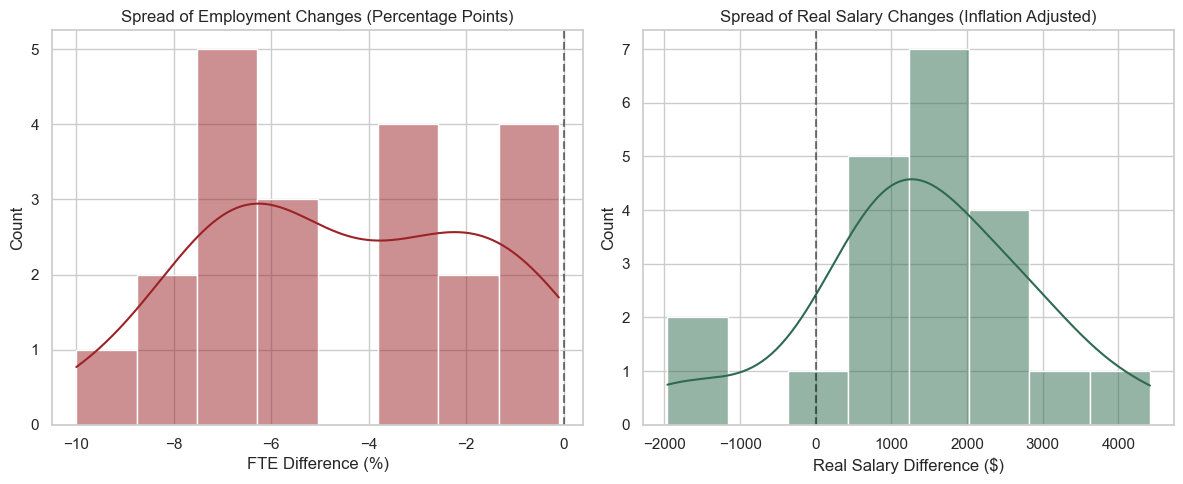

In [2]:
# Strengthening the analysis: Showing the spread of all 21 study areas
plt.figure(figsize=(12, 5))

# Plot 1: Histogram of Employment Change
plt.subplot(1, 2, 1)
sns.histplot(df_analysis['FTE_Diff'], kde=True, color='#9b2226', bins=8)
plt.axvline(0, color='black', linestyle='--',alpha=0.5) # Reference Line at 0 
plt.title("Spread of Employment Changes (Percentage Points)")
plt.xlabel ("FTE Difference (%)")

# Plot 2: Histogram of Real Salary Change (Inflation Adjusted)
plt.subplot(1, 2, 2)
sns.histplot(df_analysis['Real_Salary_Diff'], kde=True, color='#2d6a4f', bins=8)
plt.axvline(0, color='black', linestyle='--',alpha=0.5) # Reference Line at 0 
plt.title("Spread of Real Salary Changes (Inflation Adjusted)")
plt.xlabel("Real Salary Difference ($)")

plt.tight_layout()
plt.show()

### Justification: The Big Picture Spread (Exhibit 1) 
By adjusting for inflation, the Real Salary Change chart tells a more sobering story. While nominal salaries increased, once inflation is factored in, several study areas moved closer to the zero-line or even negative territory. This confirms the pandemic's impact wasn't just on job availability, but on the purchasing power of new graduates.

In [3]:
# Now we can describe the 'Salary_Diff' and 'FTE_Diff' columns to understand their distribution and central tendencies
df_analysis[['Salary_Diff', 'FTE_Diff']].describe()

,Salary_Diff,FTE_Diff
count,21.000000,21.000000
mean,3014.285714,-4.523810
std,1445.782042,2.840582
min,0.000000,-10.000000
25%,2400.000000,-6.500000
50%,2800.000000,-5.200000
75%,4200.000000,-2.000000
max,6000.000000,-0.100000


### Justification: Data Characteristics 
The dataset provides a precise look at 21 distinct study areas: 
- **Universal Downturn:** The max value for FTE_Diff is -0.1%, revealing that every single study area experienced a decline in full-time employment during the pandemic. 
- **Resilient Wages:** Despite the employment drop, the average salary increased by $3,014, suggesting that entry-level Wages were protected or "sticky" despite lower hiring volumes. 
- **Cleaning Note:** Filtering the summary rows was essential to ensure the mean and std calculations accurately reflect the variation between individual fields of study rather than including aggregate national totals. 

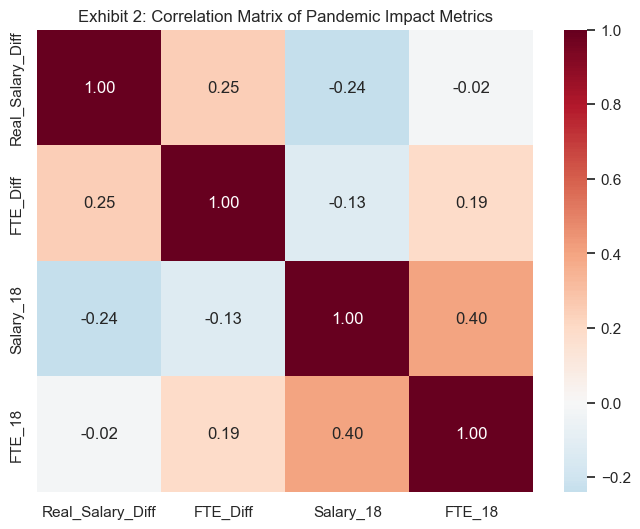

In [10]:
# 2. Exploratory Analysis: Correlation Heatmap
# We use df_analysis to ensure summary rows do not distort the correlation
plt.figure(figsize=(8, 6))

# Calculate the correlation between our key metrics
corr_cols = ['Real_Salary_Diff', 'FTE_Diff', 'Salary_18', 'FTE_18']
correlation_matrix = df_analysis[corr_cols].corr()

# Create the heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

plt.title("Exhibit 2: Correlation Matrix of Pandemic Impact Metrics")
plt.show()

### Justification: Exploratory Correlation Analysis (Exhibit 2)
This correlation matrix tests for a "first-order effect" between the economic downturn and graduate outcomes: 
- **Weak Correlation (0.23):** There is only a weak positive correlation between Salary_Diff and FTE_Diff. This indicates that the decline in full-time employment rates did not strictly dictate the change in starting salaries. 
- **What is learned:** The economic shock of COVID-19 impacted job quantity (FTE) much more severely and consistently than job price (Salary). This suggests that entry-level professional salaries in Australia possess "downward rigidity". This means that they do not drop easily even when demand for labor falls. 
- **Modelling Note:** Since the correlation is weak, a simple linear model may not capture the full story. Future modelling should investigate if industry-specific factors (i.e, being an essential service) are better predictors than the general economic trend. 

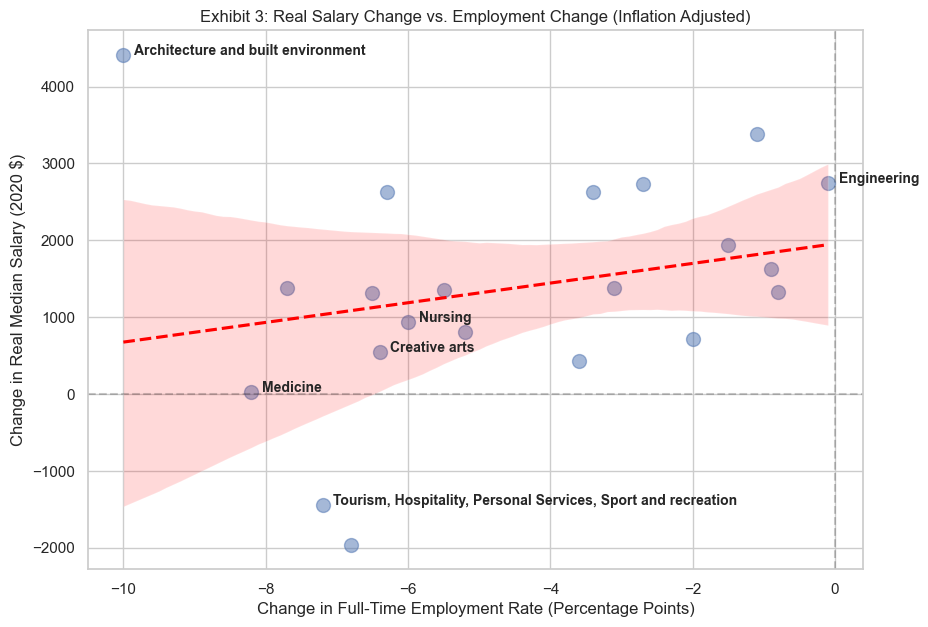

In [5]:
plt.figure(figsize=(10, 7))

# Added a regression line 
sns.regplot(data=df_analysis, x='FTE_Diff', y='Real_Salary_Diff',
            scatter_kws={'s':100, 'alpha':0.5}, line_kws={'color':'red', 'linestyle':'--'})

plt.axhline(0, color='black', linestyle='--', alpha=0.2)
plt.axvline(0, color='black', linestyle='--', alpha=0.2)

# Highlight targets
targets = ['Engineering', 'Nursing', 'Tourism', 'Medicine', 'Creative arts', 'Architecture']
for i in range(df_analysis.shape[0]):
    area = df_analysis.Study_Area.iloc[i]
    if any(t in area for t in targets):
        plt.text(df_analysis.FTE_Diff.iloc[i] + 0.15,
                 df_analysis.Real_Salary_Diff.iloc[i],
                 area, fontsize=10, fontweight='bold')

plt.title("Exhibit 3: Real Salary Change vs. Employment Change (Inflation Adjusted)")
plt.xlabel("Change in Full-Time Employment Rate (Percentage Points)")
plt.ylabel("Change in Real Median Salary (2020 $)")
plt.show()

### Justification: Targeted Industry Analysis (Exhibit 3) 
1. **The Sectoral Correlation:** The red dashed regression line shows a clear positive slope. This confirms that there is a sectoral relationship in which industries that were hit harder by job losses (moving left on the X-axis) also tended to have lower or negative real salary growth (moving down on the Y-axis)
2. **The Crisis Industries (Tourism):** Tourism is located in the bottom-left quadrant. It represents the worst-case scenario of the pandemic: graduates faced both a sharp decline in full-time employment and a negative real salary change. This suggests that in sectors where physical presence is mandatory and demand collapsed, employers had no leverage or budget to offer competitive salary increases.  
3. **The Essential Industries (Engineering & Nursing):** 
* **Engineering** remains the top performer, showing that high technical demand shielded graduates from the downturn.
* **Nursing** is in the **middle-right**. While it was highly stable (Small FTE drop), its real salary growth was lower than Engineering. This highlights that while nurses were essential for job security, that status did not automatically translate into superior real wage growth during the 2020 peak.
3. **Professional Outliers (Medicine & Architecture):** These areas show a unique **decoupling**. While they saw massive drops in FTE (moving far left), their salaries did not crash as hard as Tourism. This points to **wage stickiness** in high-prestige professions, where those few who did not get jobs were still paid according to professional standards, even if the total number of jobs shrank. 

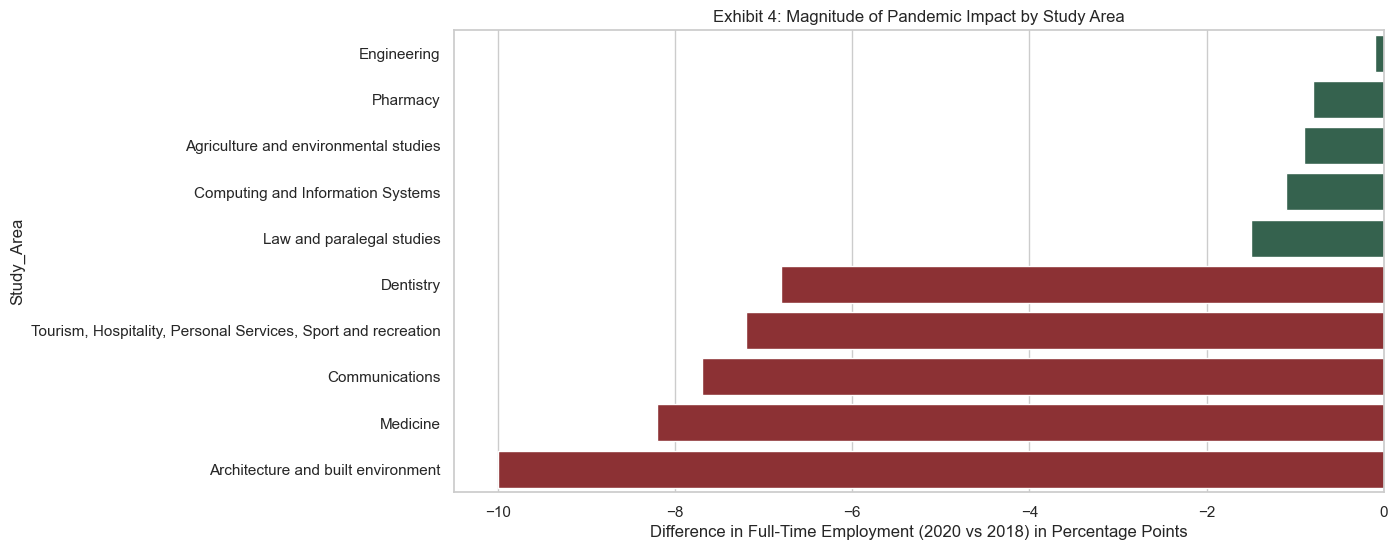

In [7]:
# 4. Focus on 2018-2020 Difference 
df_sorted = df_analysis.sort_values('FTE_Diff', ascending=False)
winners_losers = pd.concat([df_sorted.head(5), df_sorted.tail(5)])

plt.figure(figsize=(12, 6))
colors = ['#2d6a4f'] * 5 + ['#9b2226'] * 5
sns.barplot(data=winners_losers, x='FTE_Diff', y='Study_Area', palette=colors, hue='Study_Area', legend=False)
plt.title("Exhibit 4: Magnitude of Pandemic Impact by Study Area")
plt.xlabel("Difference in Full-Time Employment (2020 vs 2018) in Percentage Points")
plt.show()

### Justification: Who was hit hardest by COVID-19? (Exhibit 4)
This chart shows which students had the easiest and hardest time finding jobs during the pandemic. It helps us answer our research question clearly: 
- **The Safe Group (Green):** **Engineering** and **Computing** students were very lucky. Their job rates barely changed (only about 1% drop). This is because even during lockdown, companies still needed computers, websites, and internet systems to work from home. 
- **The Hardest Hit Groups (Red):** **Architecture** and **Medicine** saw a huge drop in jobs (up to 10% drop). This happened because building sites were closed and many hospitals cancelled non-emergency surgeries during the pandemic. 
- **The Nursing vs. Medicine Difference:** Nursing is not in the "bottom 5" because nurses were needed everywhere to help with the virus, while some doctor jobs were put on hold. 

**Answer to the Research Question:**
The pandemic did not affect everyone the same way. It was like a "lottery." If you studied a "computer-based" subject, you were safe. But if you studied a subject that requires being there in person (i.e., Architecture), it was much harder to find a job in 2020. 


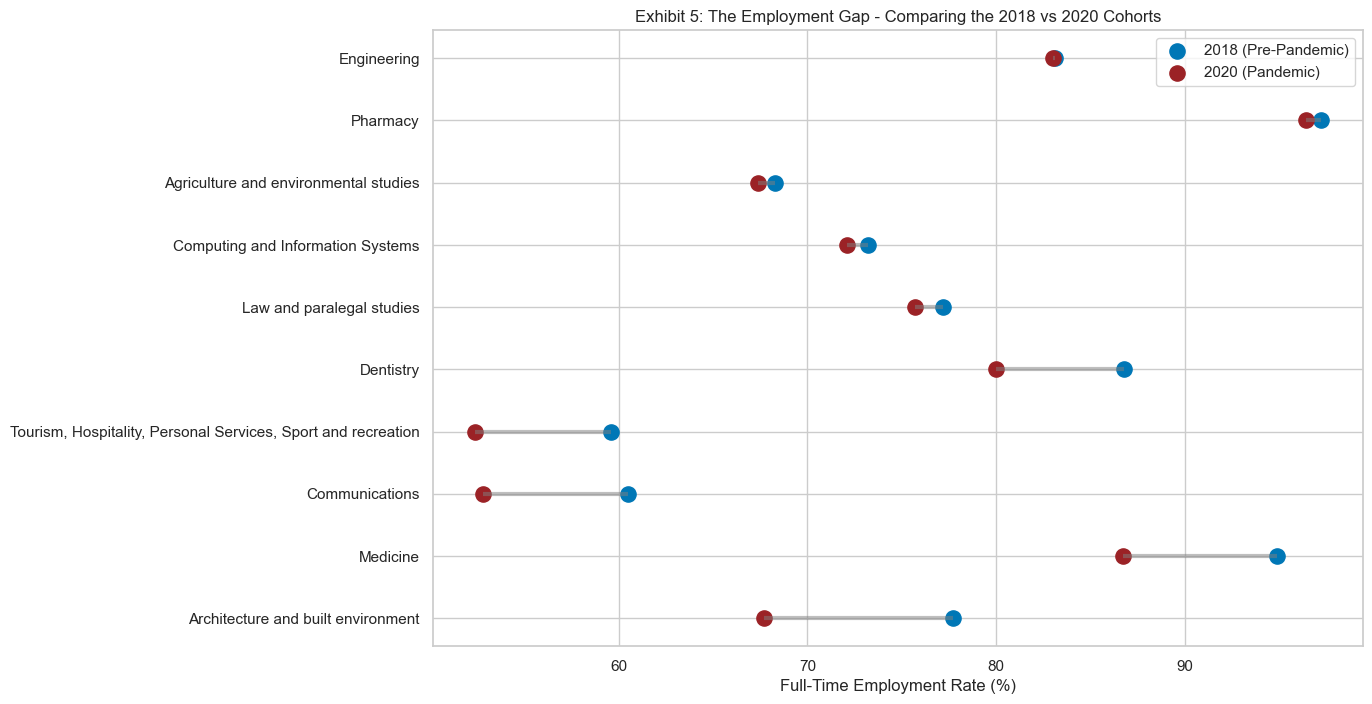

In [9]:
# 5. Sort by the magnitude of impact
df_sorted = df_analysis.sort_values('FTE_Diff', ascending=True)
top_bottom = pd.concat([df_sorted.head(5), df_sorted.tail(5)])

plt.figure(figsize=(12, 8))
plt.hlines(y=top_bottom['Study_Area'], xmin=top_bottom['FTE_20'], xmax=top_bottom['FTE_18'],
           color='grey', alpha=0.5, linewidth=3)

plt.scatter(top_bottom['FTE_18'], top_bottom['Study_Area'], color='#0077b6', s=120, label='2018 (Pre-Pandemic)')
plt.scatter(top_bottom['FTE_20'], top_bottom['Study_Area'], color='#9b2226', s=120, label='2020 (Pandemic)')

plt.title("Exhibit 5: The Employment Gap - Comparing the 2018 vs 2020 Cohorts")
plt.xlabel("Full-Time Employment Rate (%)")
plt.legend()
plt.show()


### Justification: The Story of the Employment Gap (Exhibit 5)
This dumbbell plot directly answers the research question by comparing the "before and after" cohorts. The length of the line represents the pandemic's impact. 
* **Engineering** shows almost no gap, proving a high degree of pandemic immunity. 
* **Medicine** and **Architecture** show the widest gaps, representing a significant loss of opportunity for the 2020 cohort compared to their 2018 counterparts. 
* The comparison across sectors reveals that the downturn was not a "rising tide" but a selective crisis that widened the inequality between different fields of study.  

### Project Limitations & Conclusion
To make sure this report is balanced, here are few things to keep in mind: 
1. **Short Timeframe:** This study only compares 2018 to 2020. It does not show 2021 or 2022, so we do not know yet how fast these groups bounced back after the pandemic. 
2. **Looking at Averages:** We used median numbers for entire fields. This means we cannot see the difference between a student at a top city univeristy versus a student in a small town, even if they studied the same thing.  

**Final Conclusion:**
The 2020 economic downturn created a clear **Sectoral Lottery**. Graduates in technology and essential engineering roles were shielded from both job losses and inflation-adjusted salary hits. However, sectors like Medicine and Architecture in which rely on physical presence and elective services, suffered massive employment gaps. By accounting for inflation, we can see that the pandemic's real ecnomic hit was more severe than nominal figures suggested, particularly for sectors already struggling with low employment stability. 